
# 02_07 — Build a Decision Tree

In this notebook, you'll create and visualize a **Decision Tree** classifier using scikit-learn's `make_moons` dataset.  
Decision Trees are interpretable and let you see how models make decisions step by step.


**Example Decision Tree - Should you wear a rain jacket?**

```
              Is it raining?
                [Root node]
                 /       \
               Yes        No
                |          \
                |        [Leaf] Do not wear jacket
                |
         Is it cold outside?
            [interior node]
            /         \
          Yes         No
           |           \
   [Leaf] Wear rain    [Leaf] Take umbrella only
           jacket
```



## Import libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier, plot_tree

## Generate the dataset

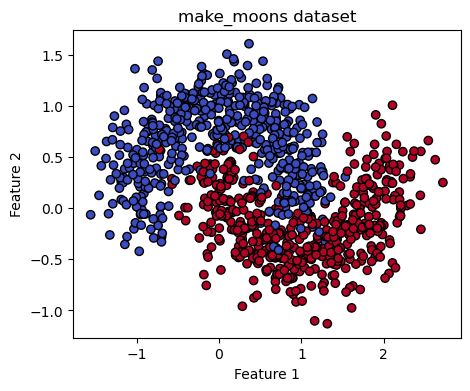

In [2]:

X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
plt.title("make_moons dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## Train a Decision Tree model

In [13]:
tree = DecisionTreeClassifier(max_depth=6, random_state=1)
tree.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

## Visualize the Decision Tree structure

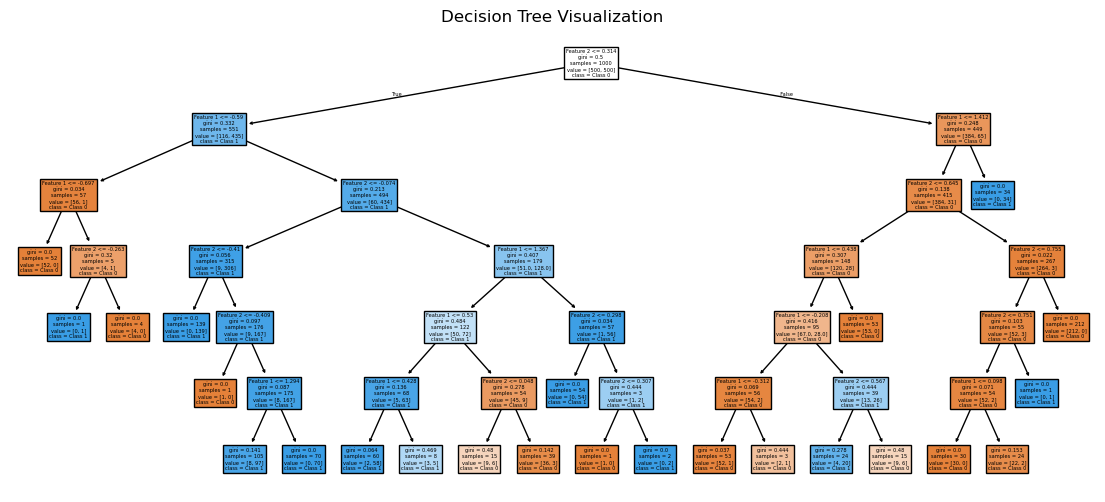

In [14]:
plt.figure(figsize=(14,6))
plot_tree(tree, filled=True, feature_names=['Feature 1', 'Feature 2'], class_names=['Class 0', 'Class 1'])
plt.title("Decision Tree Visualization")
plt.show()


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

for d in range(1, 15):
    tree = DecisionTreeClassifier(max_depth=d, random_state=1)
    tree.fit(X_train, y_train)
    preds = tree.predict(X_test)
    print(d, accuracy_score(y_test, preds))

1 0.8133333333333334
2 0.9033333333333333
3 0.9033333333333333
4 0.9033333333333333
5 0.9433333333333334
6 0.9433333333333334
7 0.9433333333333334
8 0.9266666666666666
9 0.9233333333333333
10 0.92
11 0.9166666666666666
12 0.9166666666666666
13 0.9166666666666666
14 0.9166666666666666


In [17]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

param_grid = {"max_depth": list(range(1, 16))}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=1),
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1
)
grid.fit(X, y)
print("Best depth:", grid.best_params_["max_depth"])
print("CV accuracy:", grid.best_score_)

Best depth: 6
CV accuracy: 0.9390000000000001


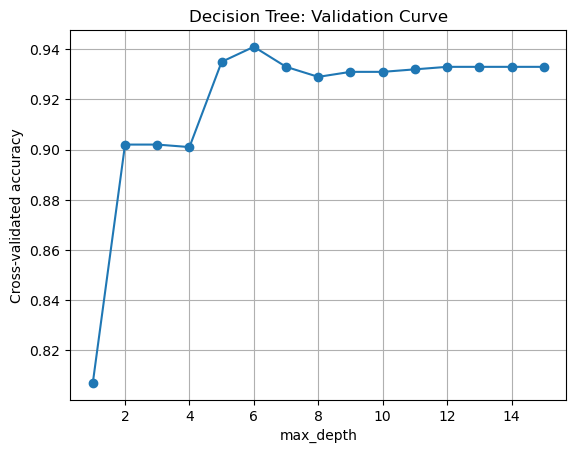

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

depths = range(1, 16)
cv_scores = [cross_val_score(
    DecisionTreeClassifier(max_depth=d, random_state=1),
    X, y, cv=5, scoring="accuracy").mean()
    for d in depths]

plt.plot(depths, cv_scores, marker="o")
plt.xlabel("max_depth")
plt.ylabel("Cross-validated accuracy")
plt.title("Decision Tree: Validation Curve")
plt.grid(True)
plt.show()

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = best_tree.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

NameError: name 'best_tree' is not defined